<a href="https://colab.research.google.com/github/pooyapaydary/mini-projects/blob/main/First_random_forest_regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [185]:
import numpy as np
import pandas as pd

np.random.seed(42)

# ---- 1. Generate 300 days ----
n = 300
dates = pd.date_range(start="2022-01-01", periods=n, freq="D")

# ---- 2. Features ----
rain = np.abs(np.random.normal(5, 10, n))          # rainfall mm
flow = np.random.normal(40, 8, n) + rain * 0.2     # flow increases with rain
turb = np.abs(np.random.normal(3, 1.5, n) + rain*0.05)   # turbidity increases with rain
ph = 7 + np.random.normal(0, 0.2, n)
temp = 10 + 10*np.sin(np.linspace(0, 3*np.pi, n)) + np.random.normal(0, 1, n)

# Categorical land use
landuse = np.random.choice(
    ["Urban", "Agriculture", "Forest", "Mixed"],
    size=n,
    p=[0.3, 0.3, 0.2, 0.2]
)

# ---- 3. Target: pollutant concentration ----
# Create a realistic relationship:
# Higher rain ↑ → higher turbidity ↑ → higher concentration
concentration = (
    0.3*rain +
    0.8*turb +
    -0.2*ph +
    0.1*temp +
    np.where(landuse=="Agriculture", 5, 0) +
    np.random.normal(0, 2, n)   # noise
)

df = pd.DataFrame({
    "Date": dates,
    "Rainfall_mm": rain.round(2),
    "Flow_Ls": flow.round(2),
    "Turbidity_NTU": turb.round(2),
    "pH": ph.round(2),
    "Temperature_C": temp.round(2),
    "LandUse": landuse,
    "Concentration_mgL": concentration.round(2)
})

df.head()


,Date,Rainfall_mm,Flow_Ls,Turbidity_NTU,pH,Temperature_C,LandUse,Concentration_mgL
0,2022-01-01,9.97,35.36,4.63,7.07,10.13,Urban,6.09
1,2022-01-02,3.62,36.24,1.80,6.92,9.89,Mixed,1.79
2,2022-01-03,11.48,48.27,4.88,7.01,10.75,Agriculture,12.16
3,2022-01-04,20.23,48.93,6.04,7.26,11.49,Urban,12.93
4,2022-01-05,2.66,40.36,3.75,7.04,11.31,Urban,1.67


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               300 non-null    datetime64[ns]
 1   Rainfall_mm        300 non-null    float64       
 2   Flow_Ls            300 non-null    float64       
 3   Turbidity_NTU      300 non-null    float64       
 4   pH                 300 non-null    float64       
 5   Temperature_C      300 non-null    float64       
 6   LandUse            300 non-null    object        
 7   Concentration_mgL  300 non-null    float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 18.9+ KB


In [187]:
X=df.drop("Concentration_mgL", axis=1)
y=df["Concentration_mgL"]

In [188]:
import pandas as pd
X["Month"] = X["Date"].dt.month
X = X.drop("Date", axis=1)
X["Rainfall_Turbidity"] = df["Rainfall_mm"] * df["Turbidity_NTU"]
X["Rainfall_per_Flow"] = X["Rainfall_mm"] / (X["Flow_Ls"] + 1)
X["Temp_pH"] = X["Temperature_C"] * X["pH"]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=.2, random_state=42 )

In [189]:
X_train = pd.get_dummies(X_train, columns=["LandUse"])
X_test = pd.get_dummies(X_test, columns=["LandUse"])

In [190]:
X_train.head()

,Rainfall_mm,Flow_Ls,Turbidity_NTU,pH,Temperature_C,Month,Rainfall_Turbidity,Rainfall_per_Flow,Temp_pH,LandUse_Agriculture,LandUse_Forest,LandUse_Mixed,LandUse_Urban
232,5.46,40.56,1.77,7.32,19.43,8,9.6642,0.131376,142.2276,False,True,False,False
59,14.76,36.33,3.52,7.09,19.53,3,51.9552,0.395392,138.4677,False,True,False,False
6,20.79,54.38,2.88,6.73,11.18,1,59.8752,0.375406,75.2414,False,True,False,False
185,12.14,31.05,5.23,7.09,5.93,7,63.4922,0.378783,42.0437,True,False,False,False
173,8.41,52.62,4.88,6.74,1.01,6,41.0408,0.156844,6.8074,False,False,True,False


In [191]:
X_test.head()

,Rainfall_mm,Flow_Ls,Turbidity_NTU,pH,Temperature_C,Month,Rainfall_Turbidity,Rainfall_per_Flow,Temp_pH,LandUse_Agriculture,LandUse_Forest,LandUse_Mixed,LandUse_Urban
203,15.54,47.61,3.08,6.97,11.87,7,47.8632,0.319687,82.7339,False,False,True,False
266,21.32,27.96,4.50,7.28,20.29,9,95.9400,0.736188,147.7112,True,False,False,False
152,1.80,32.47,1.63,7.10,0.57,6,2.9340,0.053780,4.0470,False,False,True,False
9,10.43,40.47,5.77,7.43,14.55,1,60.1811,0.251507,108.1065,True,False,False,False
233,1.52,30.62,1.92,7.09,18.15,8,2.9184,0.048071,128.6835,True,False,False,False


In [192]:
x_train, X_test=X_train.align(X_test, join="left", axis=1, fill_value=0)

array([[<Axes: title={'center': 'Rainfall_mm'}>,
        <Axes: title={'center': 'Flow_Ls'}>],
       [<Axes: title={'center': 'Turbidity_NTU'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'Temperature_C'}>, <Axes: >]],
      dtype=object)

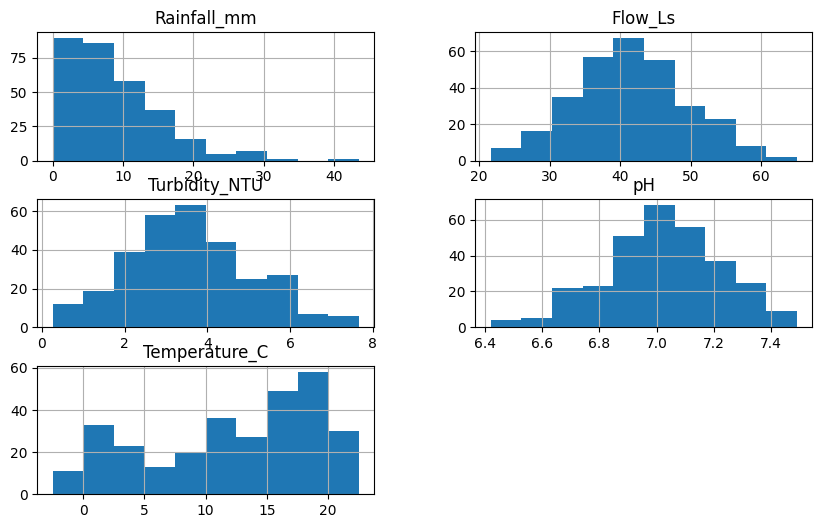

In [193]:
df[["Rainfall_mm",	"Flow_Ls",	"Turbidity_NTU",	"pH"	,"Temperature_C"]].hist(figsize=(10,6))

In [194]:
df.describe()


,Date,Rainfall_mm,Flow_Ls,Turbidity_NTU,pH,Temperature_C,Concentration_mgL
count,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2022-05-30 12:00:00,8.732433,41.574433,3.570833,7.019867,12.206467,6.687967
min,2022-01-01 00:00:00,0.020000,21.630000,0.260000,6.420000,-2.490000,-1.640000
25%,2022-03-16 18:00:00,3.547500,36.220000,2.547500,6.890000,6.767500,3.920000
50%,2022-05-30 12:00:00,7.540000,41.220000,3.535000,7.035000,14.065000,6.385000
75%,2022-08-13 06:00:00,12.415000,46.810000,4.575000,7.150000,18.260000,9.000000
max,2022-10-27 00:00:00,43.530000,65.100000,7.670000,7.490000,22.530000,20.840000
std,NaN,6.699775,7.827642,1.500567,0.202270,6.902323,3.899468


In [195]:
from xgboost import XGBRegressor
xgb=XGBRegressor (    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42)
xgb.fit(X_train, y_train)
importances=pd.Series(xgb.feature_importances_, index=X_train.columns)
importances=importances.sort_values(ascending=False)
importances

,0
LandUse_Agriculture,0.549415
Rainfall_Turbidity,0.155143
Rainfall_mm,0.042832
Rainfall_per_Flow,0.041668
LandUse_Urban,0.035408
Turbidity_NTU,0.032281
LandUse_Forest,0.029282
Temp_pH,0.027198
Temperature_C,0.022111
Month,0.020193


In [196]:
from sklearn.feature_selection import mutual_info_regression
import pandas as pd

# Compute MI
mi = mutual_info_regression(X_train, y_train, random_state=42)

# Convert to pandas Series
mi = pd.Series(mi, index=X_train.columns)

# Sort descending
mi_sorted = mi.sort_values(ascending=False)

print(mi_sorted)


Rainfall_Turbidity     0.202985
LandUse_Agriculture    0.184682
Rainfall_mm            0.178957
Turbidity_NTU          0.135610
Rainfall_per_Flow      0.124267
LandUse_Urban          0.059469
pH                     0.042194
LandUse_Mixed          0.012550
Flow_Ls                0.000000
Temperature_C          0.000000
Month                  0.000000
Temp_pH                0.000000
LandUse_Forest         0.000000
dtype: float64


In [197]:
features_to_drop = ["Flow_Ls", "Month", "LandUse_Forest", "LandUse_Mixed"]

X_train = X_train.drop(columns=features_to_drop)
X_test  = X_test.drop(columns=features_to_drop)


In [198]:
from sklearn.preprocessing import RobustScaler
numeric_cols = ["Rainfall_mm", "Turbidity_NTU", "pH", "Temperature_C"]
rb=RobustScaler()
X_train[numeric_cols]=rb.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]=rb.transform(X_test[numeric_cols])

In [199]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(max_depth=6, n_estimators=800, random_state=42)

In [200]:
y_pred=rf.predict(X_test)

In [201]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
mae

1.6407224179646913

In [204]:
y_train_pred = rf.predict(X_train)
train_mae = mean_absolute_error(y_train, y_train_pred)
print("Train MAE:", train_mae)

y_test_pred = rf.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
print("Test MAE:", test_mae)


Train MAE: 1.042039377668813
Test MAE: 1.6407224179646913


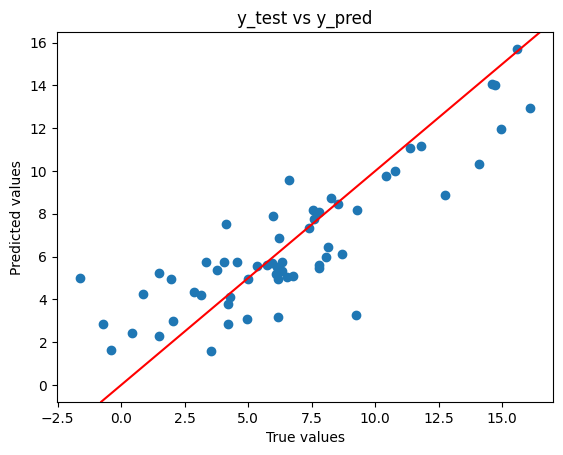

In [205]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("y_test vs y_pred")
plt.axline((0,0), slope=1, color='red')  # perfect line
plt.show()
